# Vehicle Rental Damage Audit System (YOLOv8 + Classical Plate OCR)
This notebook:
1) Detects vehicle number plate (vehicle_id)
2) Detects damages using a trained YOLOv8 model
3) Stores BEFORE damages per vehicle_id
4) Compares AFTER vs BEFORE to output NEW damages

## Imports

In [1]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO
import easyocr

%matplotlib inline

## Paths & Config

In [2]:
PROJECT_ROOT = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO"

BEST_WEIGHTS = os.path.join(PROJECT_ROOT, "models", "runs", "car_damage_yolov8s", "weights", "best.pt")

DB_PATH = os.path.join(PROJECT_ROOT, "assets", "damage_audit_db.json")

print("BEST_WEIGHTS:", BEST_WEIGHTS)
print("DB_PATH:", DB_PATH)

BEST_WEIGHTS: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\models\runs\car_damage_yolov8s\weights\best.pt
DB_PATH: D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\assets\damage_audit_db.json


## Load Models

In [3]:
# YOLO model (damage detection)
damage_model = YOLO(BEST_WEIGHTS)

# OCR reader (plate text)
ocr_reader = easyocr.Reader(['en'], gpu=True)

## Text Cleaning + Plate Text Validation

In [4]:
def clean_plate_text(text):
    if text is None:
        return ""
    text = text.upper().strip()
    # keep only A-Z 0-9
    text = "".join([c for c in text if c.isalnum()])
    return text

def is_valid_plate_text(text):
    """
    Strict enough to reject junk like "U7", but accept real IDs like "CAV1393".
    Requires both letters and digits, and length >= 4.
    """
    if text is None:
        return False
    text = clean_plate_text(text)
    if len(text) < 4:
        return False
    has_alpha = any(c.isalpha() for c in text)
    has_digit = any(c.isdigit() for c in text)
    return has_alpha and has_digit

## Plate Candidate Scoring + Candidate Detection

In [5]:
def plate_likeness_score(gray, x, y, w, h):
    patch = gray[y:y+h, x:x+w]
    if patch.size == 0:
        return -1.0

    brightness = float(np.mean(patch))
    sobelx = cv2.Sobel(patch, cv2.CV_32F, 1, 0, ksize=3)
    edge_strength = float(np.mean(np.abs(sobelx)))

    aspect = w / (h + 1e-6)
    aspect_score = 1.0 if 2.0 <= aspect <= 6.5 else 0.4

    return 0.4 * brightness + 0.4 * edge_strength + 0.2 * aspect_score


def get_plate_candidates(image_bgr, debug=False):
    img = image_bgr.copy()
    H, W = img.shape[:2]

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 11, 17, 17)

    kernels = [
        cv2.getStructuringElement(cv2.MORPH_RECT, (9, 3)),
        cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5)),
        cv2.getStructuringElement(cv2.MORPH_RECT, (17, 7)),
    ]
    blackhats = [cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, k) for k in kernels]
    blackhat = np.max(np.stack(blackhats, axis=0), axis=0).astype(np.uint8)

    gradX = cv2.Sobel(blackhat, ddepth=cv2.CV_32F, dx=1, dy=0, ksize=3)
    gradX = np.absolute(gradX)
    gradX = (255 * (gradX / (gradX.max() + 1e-9))).astype("uint8")

    gradX = cv2.GaussianBlur(gradX, (5, 5), 0)
    _, thresh = cv2.threshold(gradX, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    closeK = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 3))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, closeK, iterations=2)
    openK = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    closed = cv2.morphologyEx(closed, cv2.MORPH_OPEN, openK, iterations=1)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    candidates = []
    img_area = float(W * H)

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        area = float(w * h)
        aspect = w / float(h + 1e-9)
        area_ratio = area / (img_area + 1e-9)

        if w < 60 or h < 20:
            continue
        if not (2.0 <= aspect <= 7.0):
            continue
        if not (0.0005 <= area_ratio <= 0.25):
            continue

        score = plate_likeness_score(gray, x, y, w, h)
        candidates.append((x, y, w, h, score))

    candidates.sort(key=lambda t: t[4], reverse=True)

    if debug:
        vis = img.copy()
        for (x, y, w, h, s) in candidates[:10]:
            cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(vis, f"{s:.1f}", (x, max(0, y - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title("Top Plate Candidates (Scored)")
        plt.axis("off")
        plt.show()

    return candidates

## OCR Plate Best

In [6]:
def ocr_plate_best(image_bgr, debug=False, max_candidates=8):
    boxes = get_plate_candidates(image_bgr, debug=debug)

    best_text, best_score, best_bbox = None, 0.0, None

    for (x, y, w, h, _) in boxes[:max_candidates]:
        pad = int(0.10 * w)
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(image_bgr.shape[1], x + w + pad)
        y2 = min(image_bgr.shape[0], y + h + pad)

        roi = image_bgr[y1:y2, x1:x2]
        if roi.size == 0:
            continue

        roi = cv2.resize(roi, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
        roi = cv2.bilateralFilter(roi, 9, 75, 75)
        rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

        results = ocr_reader.readtext(rgb, detail=1)
        if not results:
            continue

        tokens, confs = [], []
        for (_, txt, cf) in results:
            cleaned = clean_plate_text(txt)
            if cleaned:
                tokens.append(cleaned)
                confs.append(float(cf))

        if not tokens:
            continue

        merged_text = "".join(tokens)
        avg_conf = float(np.mean(confs))

        if debug:
            plt.figure(figsize=(6, 2))
            plt.imshow(rgb)
            plt.title(f"OCR: {merged_text} (avg_conf={avg_conf:.2f})")
            plt.axis("off")
            plt.show()

        if not is_valid_plate_text(merged_text):
            continue

        score = avg_conf + 0.05 * len(merged_text)
        if score > best_score:
            best_text = merged_text
            best_score = score
            best_bbox = [int(x1), int(y1), int(x2), int(y2)]

    if best_text is not None:
        best_text = clean_plate_text(best_text)

    return best_text, best_score, best_bbox

## Damage Detection using YOLO

In [7]:
def detect_damages(image_bgr, conf=0.25):
    results = damage_model(image_bgr, verbose=False)[0]
    dets = []

    if results.boxes is None:
        return dets

    for b in results.boxes:
        cls_id = int(b.cls.item())
        cls_name = damage_model.names[cls_id]
        score = float(b.conf.item())
        if score < conf:
            continue

        x1, y1, x2, y2 = map(float, b.xyxy[0].tolist())
        dets.append({
            "class": cls_name,
            "conf": score,
            "bbox": [x1, y1, x2, y2]
        })

    return dets

## DB + IoU + New Damage Logic

In [8]:
def load_db(db_path=DB_PATH):
    if os.path.exists(db_path):
        with open(db_path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def save_db(db, db_path=DB_PATH):
    os.makedirs(os.path.dirname(db_path), exist_ok=True)
    with open(db_path, "w", encoding="utf-8") as f:
        json.dump(db, f, indent=2)

def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2-ix1), max(0.0, iy2-iy1)
    inter = iw * ih
    areaA = max(0.0, ax2-ax1) * max(0.0, ay2-ay1)
    areaB = max(0.0, bx2-bx1) * max(0.0, by2-by1)
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

def find_new_damages(before, after, iou_thr=0.5):
    used_before = set()
    new_after = []

    for a in after:
        best_j, best_iou = None, 0.0
        for j, b in enumerate(before):
            if j in used_before:
                continue
            if b["class"] != a["class"]:
                continue
            v = iou_xyxy(b["bbox"], a["bbox"])
            if v > best_iou:
                best_iou, best_j = v, j

        if best_j is not None and best_iou >= iou_thr:
            used_before.add(best_j)
        else:
            new_after.append(a)

    return new_after

## Register BEFORE + Check AFTER

In [9]:
def register_before(before_img_path, damage_conf=0.25, plate_min_conf=0.35, debug_plate=False):
    img = cv2.imread(before_img_path)
    if img is None:
        raise FileNotFoundError(before_img_path)

    plate, pscore, pbbox = ocr_plate_best(img, debug=debug_plate)
    if plate is None or pscore < plate_min_conf:
        return {"error": "Plate OCR failed. Use clearer plate image."}

    damages = detect_damages(img, conf=damage_conf)

    db = load_db()
    db[plate] = {
        "plate_score": pscore,
        "plate_bbox": pbbox,
        "before_image": before_img_path,
        "before_damages": damages
    }
    save_db(db)

    return {"vehicle_id": plate, "plate_score": pscore, "saved_before_count": len(damages)}


def get_new_damages(after_img_path, damage_conf=0.25, plate_min_conf=0.35, iou_thr=0.5, debug_plate=False):
    img = cv2.imread(after_img_path)
    if img is None:
        raise FileNotFoundError(after_img_path)

    plate, pscore, pbbox = ocr_plate_best(img, debug=debug_plate)
    db = load_db()

    if len(db) == 0:
        return {"error": "Database is empty. Register BEFORE image first."}

    # Case 1: OCR succeeded and plate exists in DB
    if plate is not None and is_valid_plate_text(plate) and pscore >= plate_min_conf and plate in db:
        matched_plate = plate

    # Case 2: OCR weak/failed → fallback if only one vehicle exists
    elif len(db) == 1:
        matched_plate = list(db.keys())[0]

    else:
        return {"error": "Plate OCR failed and multiple vehicles exist. Manual verification required."}

    before_damages = db[matched_plate]["before_damages"]
    after_damages  = detect_damages(img, conf=damage_conf)
    new_damages    = find_new_damages(before_damages, after_damages, iou_thr=iou_thr)

    db[matched_plate]["last_after_image"] = after_img_path
    db[matched_plate]["last_after_damages"] = after_damages
    db[matched_plate]["new_damages_last_check"] = new_damages
    save_db(db)

    return {
        "vehicle_id": matched_plate,
        "before_damages": before_damages,
        "after_damages": after_damages,
        "new_damages": new_damages
    }

## Visualization Helpers

In [10]:
def visualize_damages(image_path, damages, title="Damage Detection"):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(image_path)

    results = damage_model(img, verbose=False)
    annotated = results[0].plot()

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def print_damage_list(damages, header="Damage List"):
    print(f"\n{header}")
    print("-" * len(header))
    if not damages:
        print("No damages detected.")
        return
    for i, d in enumerate(damages, 1):
        print(f"{i}. {d['class']} | conf={d['conf']:.2f} | bbox={d['bbox']}")

## Plate Detection Visual

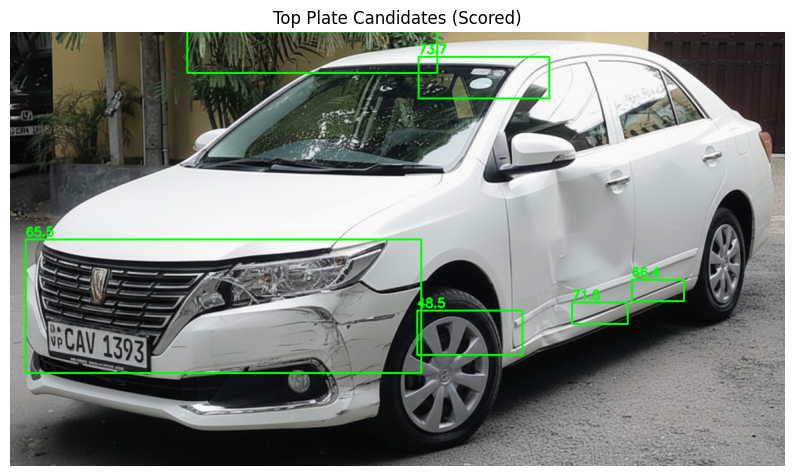

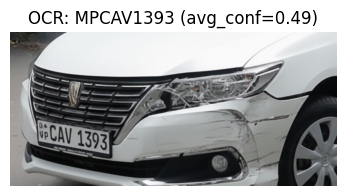

('MPCAV1393', 0.9444394066613222, [0, 251, 672, 568])

In [11]:
after_img = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\assets\after.png"

img = cv2.imread(after_img)
plate_out = ocr_plate_best(img, debug=True, max_candidates=8)
plate_out

## Damage Detection Visual with Plate ID

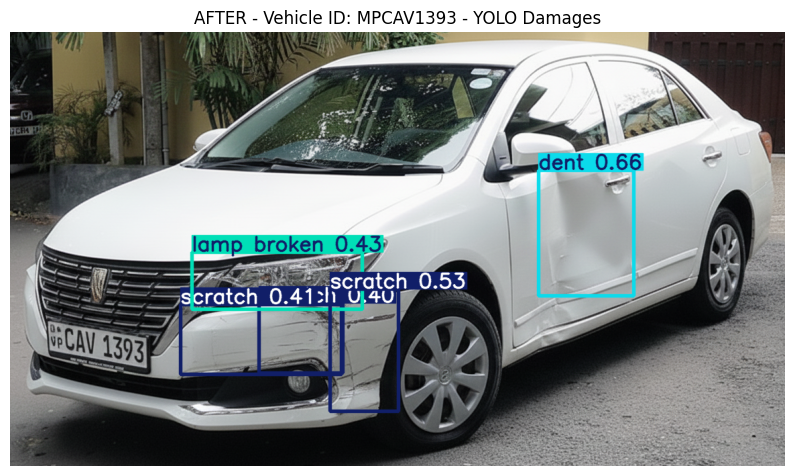


AFTER Damages (vehicle_id=MPCAV1393)
------------------------------------
1. dent | conf=0.66 | bbox=[788.104736328125, 207.6453857421875, 930.9102172851562, 394.2262268066406]
2. scratch | conf=0.53 | bbox=[477.5918273925781, 384.2474060058594, 579.3243408203125, 566.6740112304688]
3. lamp broken | conf=0.43 | bbox=[271.7450866699219, 329.3757629394531, 525.7465209960938, 414.42132568359375]
4. scratch | conf=0.41 | bbox=[254.04331970214844, 407.2244873046875, 494.08978271484375, 511.48944091796875]
5. scratch | conf=0.40 | bbox=[371.58660888671875, 405.5040588378906, 496.1075439453125, 509.8425598144531]


In [12]:
plate_text, plate_score, plate_bbox = plate_out

damages_after = detect_damages(cv2.imread(after_img), conf=0.35)
visualize_damages(after_img, damages_after, title=f"AFTER - Vehicle ID: {plate_text} - YOLO Damages")
print_damage_list(damages_after, header=f"AFTER Damages (vehicle_id={plate_text})")

## Full Audit Return = NEW Damages

In [13]:
# Reset DB for clean demo (run once)
# if os.path.exists(DB_PATH):
#     os.remove(DB_PATH)

before_img = r"D:\IIT\4 th Year\Machine Vision\Course Work\Car-Damage-Detection-YOLO\assets\before.jpg"

print("Register BEFORE:")
print(register_before(before_img, damage_conf=0.35, plate_min_conf=0.35, debug_plate=False))

print("\nCheck AFTER:")
audit = get_new_damages(after_img, damage_conf=0.35, plate_min_conf=0.35, iou_thr=0.5, debug_plate=False)
audit

Register BEFORE:
{'vehicle_id': 'CAV1393', 'plate_score': 1.2736309577461535, 'saved_before_count': 1}

Check AFTER:


{'vehicle_id': 'CAV1393',
 'before_damages': [{'class': 'glass shatter',
   'conf': 0.5668560266494751,
   'bbox': [139.85995483398438,
    39.43599319458008,
    368.36651611328125,
    116.77129364013672]}],
 'after_damages': [{'class': 'dent',
   'conf': 0.6633700132369995,
   'bbox': [788.104736328125,
    207.6453857421875,
    930.9102172851562,
    394.2262268066406]},
  {'class': 'scratch',
   'conf': 0.5341464877128601,
   'bbox': [477.5918273925781,
    384.2474060058594,
    579.3243408203125,
    566.6740112304688]},
  {'class': 'lamp broken',
   'conf': 0.43188920617103577,
   'bbox': [271.7450866699219,
    329.3757629394531,
    525.7465209960938,
    414.42132568359375]},
  {'class': 'scratch',
   'conf': 0.4061202108860016,
   'bbox': [254.04331970214844,
    407.2244873046875,
    494.08978271484375,
    511.48944091796875]},
  {'class': 'scratch',
   'conf': 0.39760443568229675,
   'bbox': [371.58660888671875,
    405.5040588378906,
    496.1075439453125,
    509.842

## Visualize BEFORE vs AFTER vs NEW

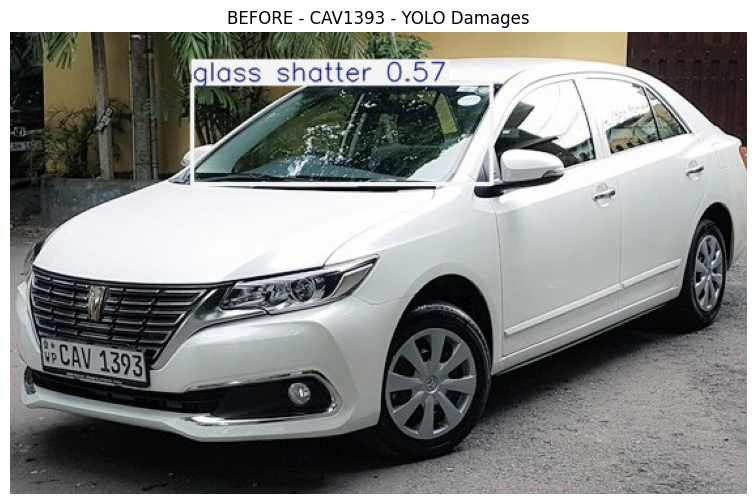

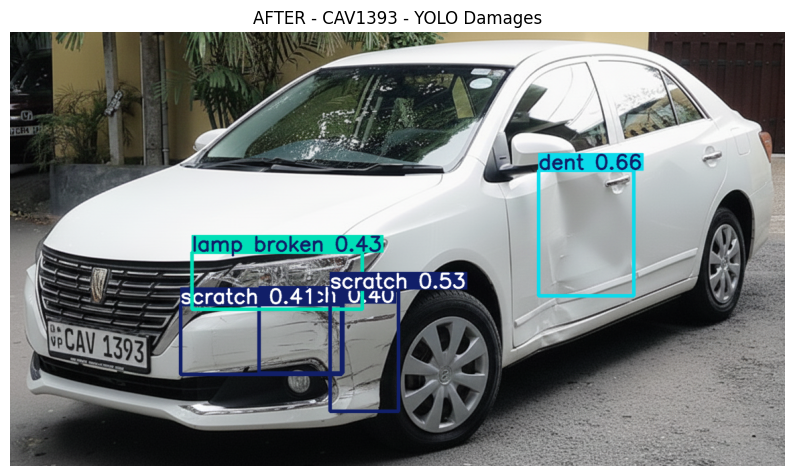

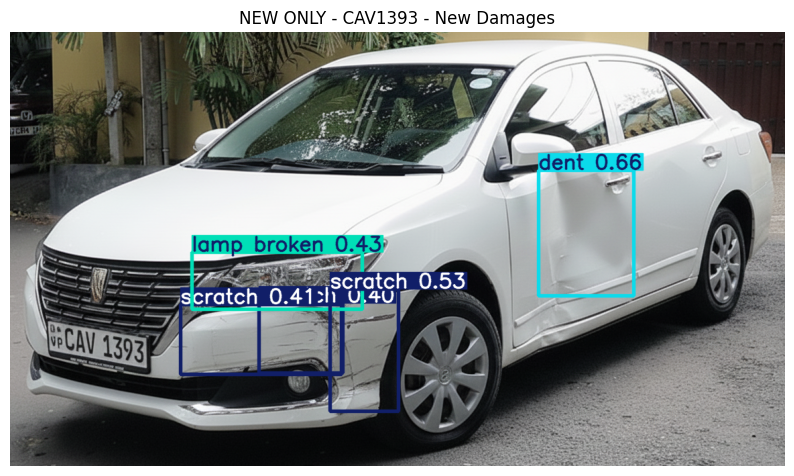


BEFORE Damages
--------------
1. glass shatter | conf=0.57 | bbox=[139.85995483398438, 39.43599319458008, 368.36651611328125, 116.77129364013672]

AFTER Damages
-------------
1. dent | conf=0.66 | bbox=[788.104736328125, 207.6453857421875, 930.9102172851562, 394.2262268066406]
2. scratch | conf=0.53 | bbox=[477.5918273925781, 384.2474060058594, 579.3243408203125, 566.6740112304688]
3. lamp broken | conf=0.43 | bbox=[271.7450866699219, 329.3757629394531, 525.7465209960938, 414.42132568359375]
4. scratch | conf=0.41 | bbox=[254.04331970214844, 407.2244873046875, 494.08978271484375, 511.48944091796875]
5. scratch | conf=0.40 | bbox=[371.58660888671875, 405.5040588378906, 496.1075439453125, 509.8425598144531]

NEW Damages Only
----------------
1. dent | conf=0.66 | bbox=[788.104736328125, 207.6453857421875, 930.9102172851562, 394.2262268066406]
2. scratch | conf=0.53 | bbox=[477.5918273925781, 384.2474060058594, 579.3243408203125, 566.6740112304688]
3. lamp broken | conf=0.43 | bbox=[271.

In [14]:
if "error" in audit:
    print(audit["error"])
else:
    visualize_damages(before_img, audit["before_damages"], title=f"BEFORE - {audit['vehicle_id']} - YOLO Damages")
    visualize_damages(after_img,  audit["after_damages"],  title=f"AFTER - {audit['vehicle_id']} - YOLO Damages")
    visualize_damages(after_img,  audit["new_damages"],    title=f"NEW ONLY - {audit['vehicle_id']} - New Damages")

    print_damage_list(audit["before_damages"], header="BEFORE Damages")
    print_damage_list(audit["after_damages"],  header="AFTER Damages")
    print_damage_list(audit["new_damages"],    header="NEW Damages Only")